<font size="6">Coding Challenge Osapiens Terra</font>

<font size="6">BFAST</font>

# Instructions
## Data Preprocessing
- Choose any of the areas, brazil or canada
- Feel free to plot the images and do some data exploration
- Make sure you are comfortable with the data
- Tipp: Make sure you clip the data to values between 0 and 1, be aware of outliers

## BFAST implementation
- The most relevant part of the algorithm is explained in Section 2.2. Season-trend model. (http://bfast.r-forge.r-project.org/Verbesselt+Zeileis+Herold-2012.pdf)
- Most likely, you will need to use some form of optimization to fit the parameters of the model.
- Feel free to use any optimization algorithm or package you want.
- Also feel free to make useful approximations/simplifications to the algorithm
- Make sure you choose appropiate hyperparamters - use the paper as a reference

# Imports

In [1]:
import pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from typing import Tuple
import json
from rasterio.transform import from_bounds
import rasterio

# Functions

Quick cheat-sheet for parameters

| Parameter          | Appears in                  | Controls                                    |
| ------------------ | --------------------------- | ------------------------------------------- |
| `alpha1`           | `params[0]` of season model | Base level                                  |
| `alpha2`           | `params[1]` (if present)    | **Trend slope**                             |
| `gamma_j`          | following `k` params        | **Amplitude** of each seasonal harmonic     |
| `delta_j`          | last `k` params             | **Phase shift** of each harmonic            |
| `k`                | All functions               | Number of harmonics (complexity of season)  |
| `f`                | All functions               | Observations per year (temporal resolution) |
| `h`                | `mosum`                     | Window size for break detection             |
| `threshold_factor` | `mosum`                     | Sensitivity (lower = more sensitive)        |


Choice of the appropriate Hyperparameters<br>
| Parameter | Value | Why? |
| --- | --- | --- |
| f (frequency) | 12 | 12 observations per year (monthly NBR)|
| k (harmonics) | 2–3 | Captures smooth seasonality without overfit|
| h (MOSUM win.) | 6 | Half a year; good for monthly data|
| Optimization | L-BFGS-B | Fast, stable for this size problem |

## season_trend_model

In [2]:
def season_trend_model(t: np.ndarray, params: np.ndarray, k: int = 3, f: int = 12) -> np.ndarray:
    """
    Compute the season-trend model: a linear trend with k seasonal sine wave harmonics.
    
    Parameters:
    - t: Time vector (e.g., day index or 16-day interval index).
    - params: Model parameters [alpha1, alpha2, gamma1..k, delta1..k].
    - k: Number of seasonal harmonics to use (default: 3).
    - f: Frequency of seasonal cycle.
    
    Returns:
    - y: Model-predicted values at each time step.
    """
    
    alpha1, alpha2 = params[:2]
    gammas = params[2:2 + k]
    deltas = params[2 + k:]
    y = alpha1 + alpha2 * t
    #y = np.full_like(t, fill_value=alpha1, dtype=float)
    
    for j in range(1, k + 1):
        y += gammas[j - 1] * np.sin(2 * np.pi * j * t / f + deltas[j - 1])
        
    return y

## loss_function

In [3]:
def loss_function(params: np.ndarray, t: np.ndarray, y_obs: np.ndarray, k: int = 3, f: int = 12) -> float:
    """
    Compute the mean squared error between observed and model-predicted values.
    
    Parameters:
    - params: Model parameters.
    - t: Time steps.
    - y_obs: Observed values.
    - k: Number of harmonics.
    - f: Frequency of seasonal cycle.
    
    Returns:
    - Mean squared error.
    """
    
    y_pred = season_trend_model(t, params, k, f)
    
    return np.mean((y_obs - y_pred) ** 2)

## fit_season_trend_optimized

| Parameter              | Initial Value | Meaning                                                      |
| ---------------------- | ------------- | ------------------------------------------------------------ |
| `alpha1` (level)       | `np.mean(y)`  | Start the model at the average of the observed data          |
| `alpha2` (slope)       | `0.0`         | Assume no trend at first (neutral baseline)                  |
| `gamma_j` (amplitudes) | `0.1` × `k`   | Small seasonal wiggles — non-zero to capture possible cycles |
| `delta_j` (phases)     | `0.0` × `k`   | Start without shifting the sine waves                        |


In [4]:
def fit_season_trend_optimized(t: np.ndarray, y: np.ndarray, k: int = 3, f: int = 12):
    """
    Fit the season-trend model to a time series using nonlinear optimization.
    
    Parameters:
    - t: Time steps.
    - y: Observed values.
    - k: Number of harmonics.
    - f: Frequency of seasonal cycle.
    
    Returns:
    - Result object from scipy.optimize.minimize containing fitted parameters and metadata.
    """
    
    init_params = [np.mean(y), 0.0] + [0.1] * k + [0.0] * k
    #init_params = [np.mean(y), 0.0] + [0.6] * k + [0.0] * k
    
    return minimize(loss_function, init_params, args=(t, y, k, f), method='L-BFGS-B')

## mosum

In [5]:
def mosum(residuals: np.ndarray, h: int, sigma_est: float, threshold_factor: float = 1.5) -> Tuple[np.ndarray, np.ndarray]:
    """
    Apply the MOSUM test to detect structural breaks.

    Parameters:
    - residuals: Residuals from the fitted model.
    - h: Window size for moving sum.
    - sigma_est: Estimated noise level (std of residuals).
    - threshold_factor: Threshold for detecting breaks.

    Returns:
    - Indices of detected breaks.
    - MOSUM statistic values.
    """
    
    mosum_values = [
        np.sum(residuals[i - h:i]) / (sigma_est * np.sqrt(h))
        for i in range(h, len(residuals))
    ]
    mosum_values = np.array(mosum_values)
    breaks = np.where(np.abs(mosum_values) > threshold_factor)[0] + h
    
    return breaks, mosum_values

# Settings 

In [6]:
band_b08 = 7
band_b12 = 11

# Paths

In [7]:
path_array = r"../data/features_canada.npy"
path_geojson = r"../data/area_canada.geojson"


output_folder = pathlib.Path(r"../output")
output_folder.mkdir(parents=True, exist_ok=True) 

path_output = output_folder / "bfast_canada.tif"

# Prepare input data

In [8]:
array = np.load(path_array)
array.shape

(72, 145, 118, 13)

## Normalized Burn Ratio 
NBR = (NIR - SWIR) / (NIR + SWIR)

**Sentienl-2** >> NBR = (B08 - B12) / (B08 + B12)

In [9]:
nbr_stack = np.zeros(array.shape[:3])

for t in range(nbr_stack.shape[0]):
    nbr = (array[t, :, :, band_b08] - array[t, :, :, band_b12]) / \
          (array[t, :, :, band_b08] + array[t, :, :, band_b12])
    nbr_stack[t,:,:] = nbr

In [10]:
# Scale values to range 0-1

def scale_to_unit_nan(arr):
    valid = arr[~np.isnan(arr)]
    min_val, max_val = valid.min(), valid.max()
    scaled = (arr - min_val) / (max_val - min_val)
    return scaled

nbr_stack = scale_to_unit_nan(nbr_stack)

assert nbr_stack[~np.isnan(nbr_stack)].min() == 0
assert nbr_stack[~np.isnan(nbr_stack)].max() == 1

## Create a timeseries from the numpy ndarray by selecting an arbitrary pixel and extracting the time series

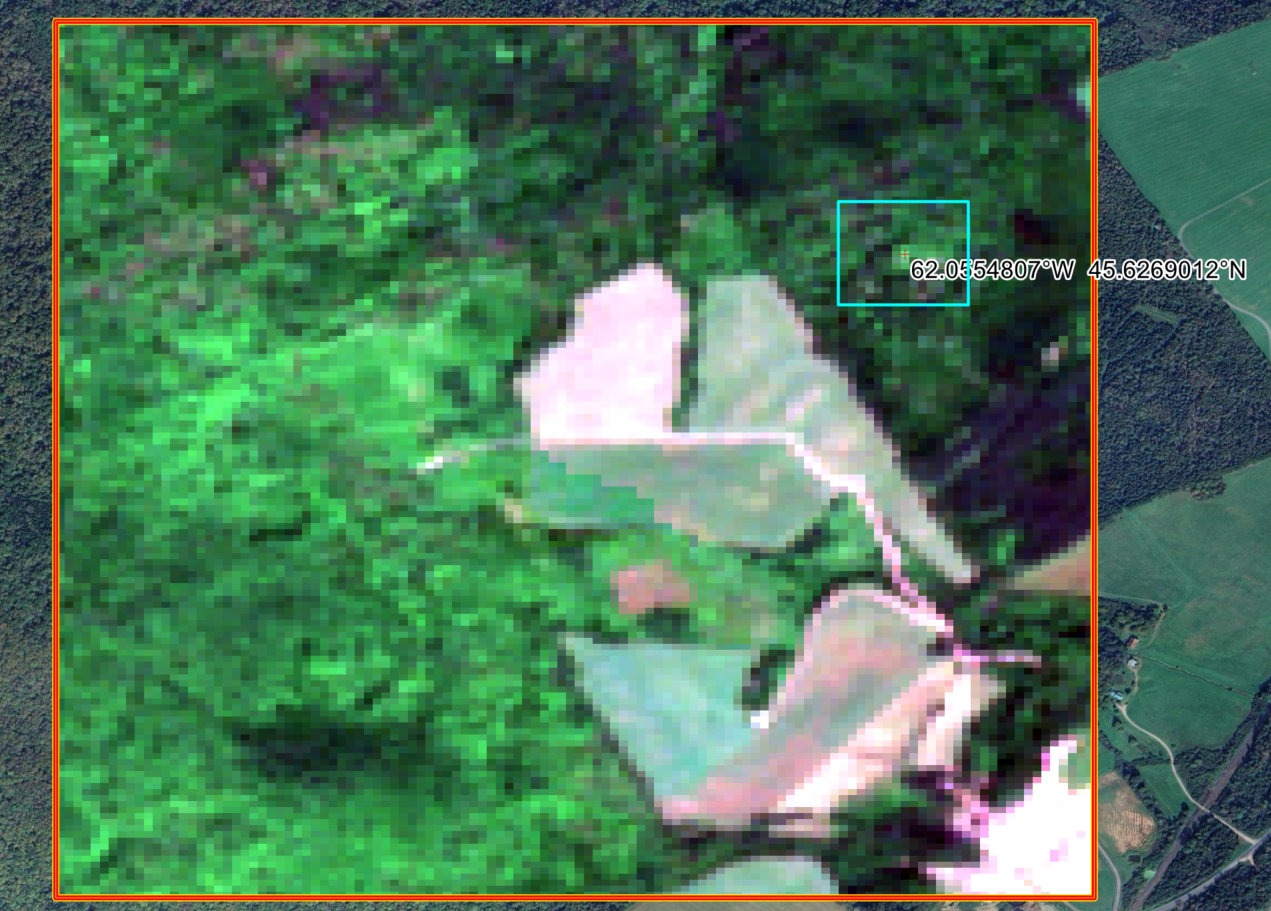

In [11]:
nbr_array = nbr_stack[:,38,96]

### NBR of different land cover classes

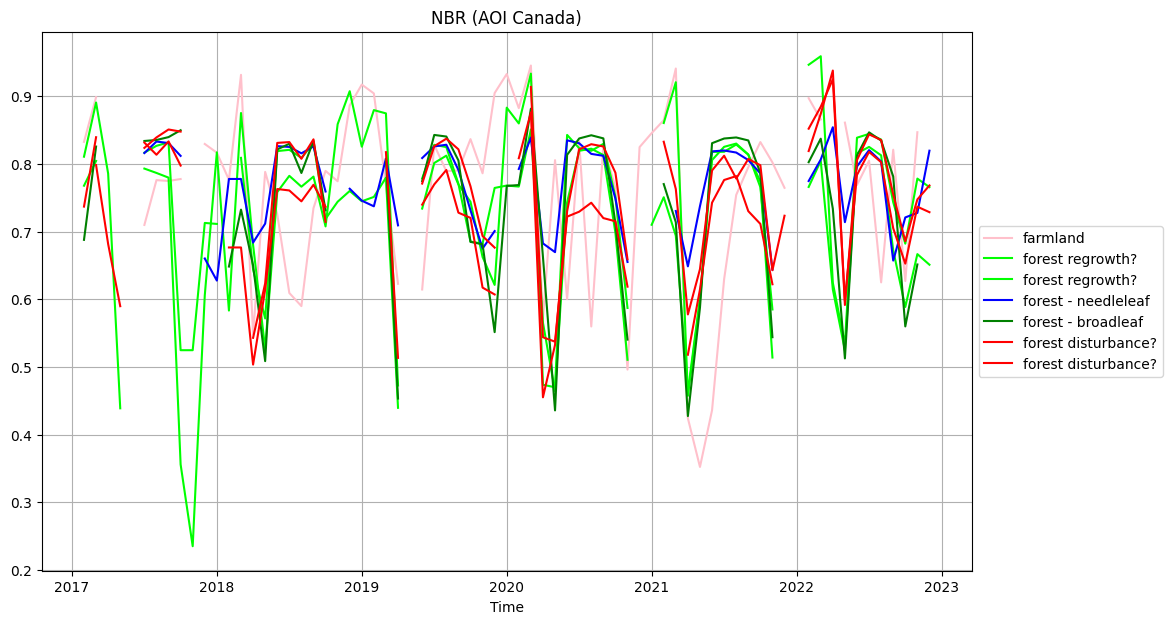

In [12]:
fig, ax = plt.subplots(1, 1, figsize=(12, 7))

ax.plot(nbr_stack[:,112,69], label='farmland', color='pink')

ax.plot(nbr_stack[:,81,25], label='forest regrowth?', color='lime')
ax.plot(nbr_stack[:,73,37], label='forest regrowth?', color='lime')

ax.plot(nbr_stack[:,131,54], label='forest - needleleaf', color="blue")
ax.plot(nbr_stack[:,127,34], label='forest - broadleaf', color='green')

ax.plot(nbr_stack[:,38,96], label='forest disturbance?', color='red')  
ax.plot(nbr_stack[:,44,93], label='forest disturbance?', color='red')  

ax.set_title('NBR (AOI Canada)')
ax.set_xlabel('Time')
ax.set_xticks(np.arange(0, 12*7, 12))
ax.set_xticklabels(np.arange(2017, 2024))
ax.grid(True)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))

plt.show()

## Build DataFrame

In [13]:
dates = pd.date_range(start='2017-01-01', periods=72, freq='M')
df_nbr = pd.DataFrame({'date': dates, 'nbr': nbr_array})

# Use 75% for history
split_index = int(len(df_nbr) * 0.75)  
split_date = df_nbr['date'].iloc[split_index]

df_history = df_nbr[df_nbr['date'] <= split_date].dropna().reset_index(drop=True)
df_monitor = df_nbr[df_nbr['date'] >= split_date].dropna().reset_index(drop=True)

if len(df_history)<24:
     raise SystemExit("Length of the history period < 2 years")

# BFAST implementation
* The most relevant part of the algorithm is explained in Section 2.2. Season-trend model. (http://bfast.r-forge.r-project.org/Verbesselt+Zeileis+Herold-2012.pdf)
* Most likely, you will need to use some form of optimization to fit the parameters of the model.
* Feel free to use any optimization algorithm or package you want.
* Also feel free to make useful approximations/simplifications to the algorithm
* Make sure you choose appropiate hyperparamters - use the paper as a reference


In [14]:
# Generate model on history period
t_hist = np.arange(len(df_history))
y_hist = df_history['nbr'].values
result = fit_season_trend_optimized(t_hist, y_hist)
params = result.x

# Predict on history + monitoring period 
y = df_nbr['nbr'].values
y_fit = season_trend_model(np.arange(len(df_nbr)), params)

# Predict on monitoring period
t_monitor = np.arange(len(df_monitor)) + len(df_history)
y_monitor = df_monitor['nbr'].values
y_monitor_fit = season_trend_model(t_monitor, params)

# Compute residuals and detect breaks
residuals = y_monitor - y_monitor_fit

sigma_est = np.std(residuals)

h=6

threshold = 1.5

breaks, mosum_values = mosum(residuals, h=h, sigma_est=sigma_est, threshold_factor=threshold)
breaks_mosum_values =  [mosum_values[b - h] for b in breaks]

# Keep only breaks where MOSUM value is negative
negative_breaks = [b for b in breaks if mosum_values[b - h] < 0]

print(f"Split date: {split_date.date()}")
print(f"Detected {len(breaks)} break(s) in the monitoring period.")
display(pd.DataFrame({"date":df_monitor['date'].iloc[breaks],"mosum": breaks_mosum_values}))

print(f"Detected {len(negative_breaks)} negative break(s) in the monitoring period.")

Split date: 2021-07-31
Detected 4 break(s) in the monitoring period.


,date,mosum
11,2022-07-31,1.710388
12,2022-08-31,2.614566
13,2022-09-30,2.807597
14,2022-10-31,2.090462


Detected 0 negative break(s) in the monitoring period.


# Plot

## Disturbance Detection

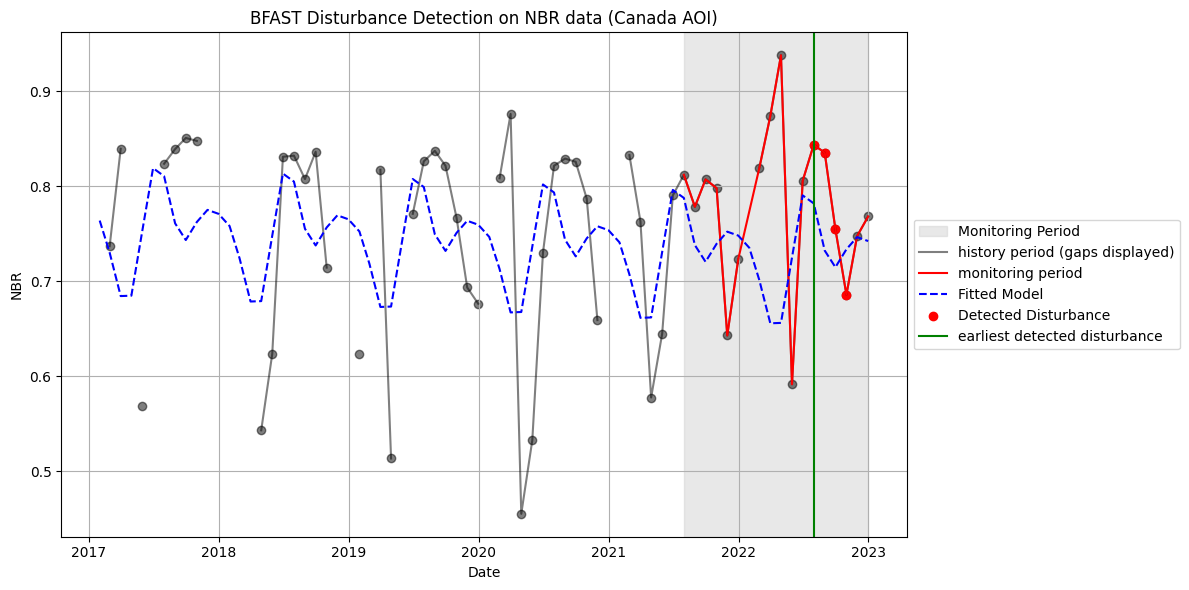

In [15]:
plt.figure(figsize=(12, 6))

# Monitoring period
plt.axvspan(df_monitor['date'].iloc[0], df_monitor['date'].iloc[-1], color='lightgray', alpha=0.5, label='Monitoring Period')

# Data
plt.plot(df_nbr['date'], df_nbr['nbr'], label='history period (gaps displayed)', color='black', alpha=0.5)
plt.plot(df_monitor['date'], df_monitor['nbr'], label='monitoring period', color='red')
plt.scatter(df_nbr['date'], df_nbr['nbr'], color='black', alpha=0.5)

# Season model
plt.plot(df_nbr['date'], y_fit, label='Fitted Model', color='blue', linestyle="--")

# Disturbances
plt.scatter(df_monitor['date'].iloc[breaks], y_monitor[breaks], color='red', label='Detected Disturbance')
plt.axvline(x=df_monitor.date[breaks[0]], color='green', label='earliest detected disturbance')


plt.title('BFAST Disturbance Detection on NBR data (Canada AOI)')
plt.xlabel('Date')
plt.ylabel('NBR')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.grid(True)
plt.tight_layout()
plt.show()

# Bonus: Apply BFAST to not just one, but all pixels in the area

In [18]:
def build_dataframe(nbr_stack, row, col):
    
    dates = pd.date_range(start='2017-01-01', periods=72, freq='M')
    df_nbr = pd.DataFrame({'date': dates, 'nbr': nbr_stack[:, row, col]})
        
    split_index = int(len(df_nbr) * 0.75)  # e.g. use 75% for history
    split_date = df_nbr['date'].iloc[split_index]
    
    df_history = df_nbr[df_nbr['date'] <= split_date].dropna().reset_index(drop=True)
    df_monitor = df_nbr[df_nbr['date'] >= split_date].dropna().reset_index(drop=True)
    
    return df_history, df_monitor

def bfast(df_history, df_monitor):

    # Generate model on history period
    t_hist = np.arange(len(df_history))
    y_hist = df_history['nbr'].values
    result = fit_season_trend_optimized(t_hist, y_hist)
    params = result.x
    
    # Predict on monitoring period
    t_monitor = np.arange(len(df_monitor)) + len(df_history)
    y_monitor = df_monitor['nbr'].values
    y_monitor_fit = season_trend_model(t_monitor, params)
    
    # Compute residuals and detect breaks
    residuals = y_monitor - y_monitor_fit
    
    sigma_est = np.std(residuals)
    
    h=6
    
    threshold = 1.5
    
    breaks, mosum_values = mosum(residuals, h=h, sigma_est=sigma_est, threshold_factor=threshold)
        
    return breaks, mosum_values

In [19]:
%%time
breaks_count = np.zeros(nbr_stack.shape[1:])

for row in range(nbr_stack.shape[1]):
    for col in range(nbr_stack.shape[2]):
        
        df_history, df_monitor = build_dataframe(nbr_stack, row, col)
        
        if len(df_history)<24:
            print("Length of the history period < 2 years")
        
        breaks, mosum_values = bfast(df_history, df_monitor)
        
        h=6
        negative_breaks = [b for b in breaks if mosum_values[b - h] < 0]
        
        breaks_count[row, col] = len(negative_breaks)

CPU times: user 5min 11s, sys: 133 ms, total: 5min 11s
Wall time: 5min 11s


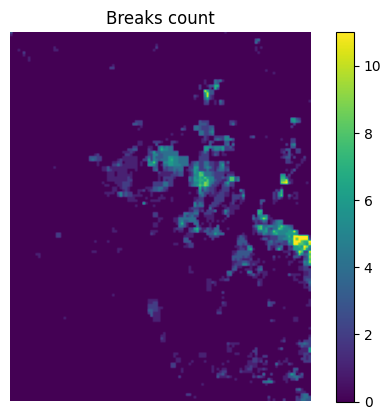

In [20]:
plt.imshow(breaks_count)
plt.title("Breaks count")
plt.colorbar()
plt.axis("off")
plt.show()

## Export to tif

In [21]:
# Load bounding box from GeoJSON
with open(path_geojson) as f:
    geojson = json.load(f)

# Extract bounding box coordinates
bbox = geojson["features"][0]["geometry"]["coordinates"][0]
min_lon, min_lat = bbox[1]
max_lon, max_lat = bbox[3]

height, width = breaks_count.shape

# Build affine transform
transform = from_bounds(min_lon, min_lat, max_lon, max_lat, width, height)

with rasterio.open(
    path_output, 'w',
    driver='GTiff',
    height=height,
    width=width,
    count=1,
    dtype=breaks_count.dtype,
    crs='EPSG:4326',
    transform=transform
) as dst:        
    dst.write(np.expand_dims(breaks_count, axis=0))

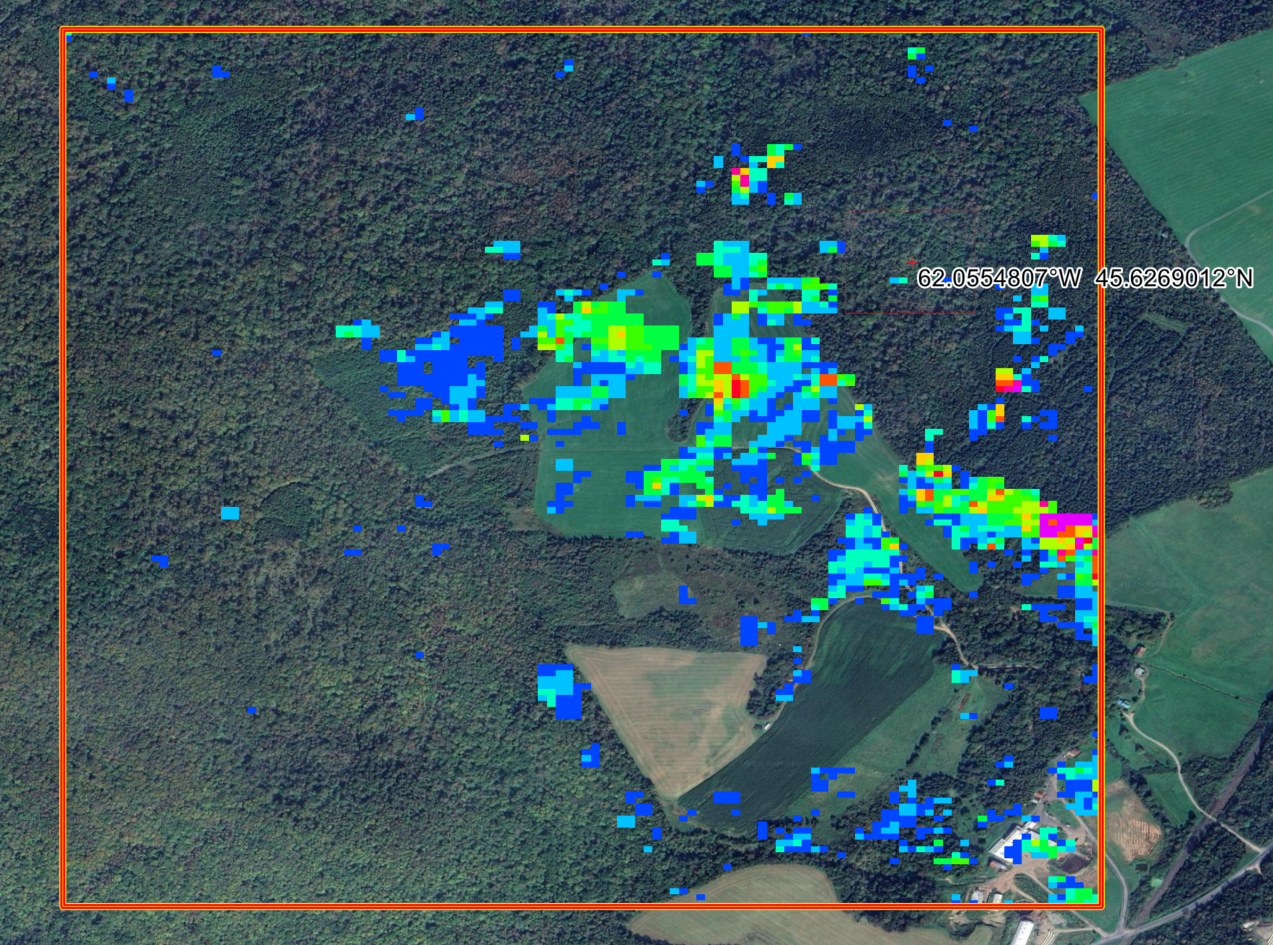